In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

In [2]:
with open('Datasets/GSE21422_series_matrix.txt', 'r') as f:
    for i, line in enumerate(f):
        if i == 36:
            label_line = line.strip()
            break

label_values = [v.replace('"', '').strip() for v in label_line.split('\t')[1:]]
y = np.array([0 if 'healthy' in v.lower() else 1 for v in label_values])

print('Unique label values:', set(label_values))
print('Label distribution  :', dict(zip(*np.unique(y, return_counts=True))))

Unique label values: {'healthy', 'tumor', 'DCIS'}
Label distribution  : {np.int64(0): np.int64(5), np.int64(1): np.int64(14)}


In [3]:
gse21422 = pd.read_csv(
    'Datasets/GSE21422_series_matrix.txt',
    sep='\t', comment='!', index_col=0
)
gse21422 = gse21422.dropna(axis=1, how='all')
gse21422_T = gse21422.T

print('Expression shape (samples x genes):', gse21422_T.shape)
assert len(y) == len(gse21422_T), f'Mismatch: {len(y)} labels vs {len(gse21422_T)} samples'
print('Label count matches sample count. OK.')

Expression shape (samples x genes): (19, 54675)
Label count matches sample count. OK.


In [5]:
X = gse21422_T.values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train_raw.shape}\nTest: {X_test_raw.shape}')

Train: (15, 54675)
Test: (4, 54675)


In [6]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

In [8]:
k = min(100, X_train_imp.shape[0] - 1)
selector = SelectKBest(f_classif, k=k)
X_train_sel = selector.fit_transform(X_train_imp, y_train)
X_test_sel  = selector.transform(X_test_imp)

print(f'Train selected: {X_train_sel.shape}\nTest selected: {X_test_sel.shape}')

Train selected: (15, 14)
Test selected: (4, 14)


In [9]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    preds = model.predict(X_test_sel)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f'\n── {name} ──')
    print(classification_report(y_test, preds, target_names=['Normal', 'Tumor']))

print('\nFinal accuracies:', results)


── Random Forest ──
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         1
       Tumor       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


── SVM ──
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         1
       Tumor       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


── Logistic Regression ──
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         1
       Tumor       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg   

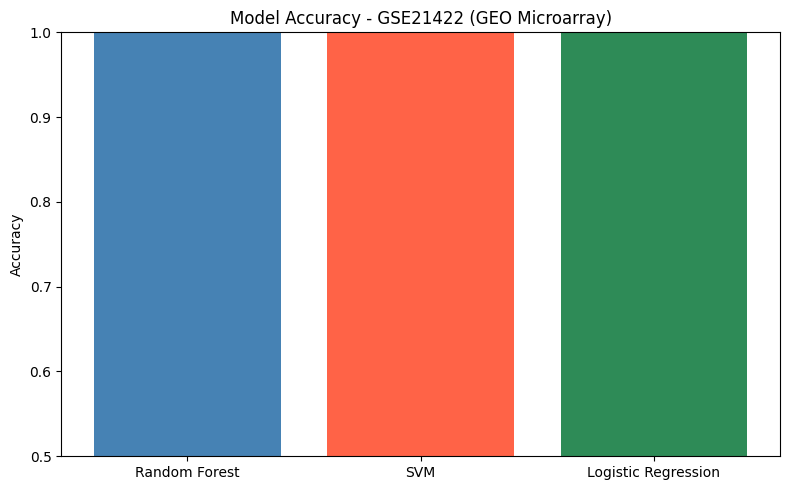

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['steelblue', 'tomato', 'seagreen'])
plt.title('Model Accuracy - GSE21422 (GEO Microarray)')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('gse21422_accuracy.png', dpi=150)
plt.show()

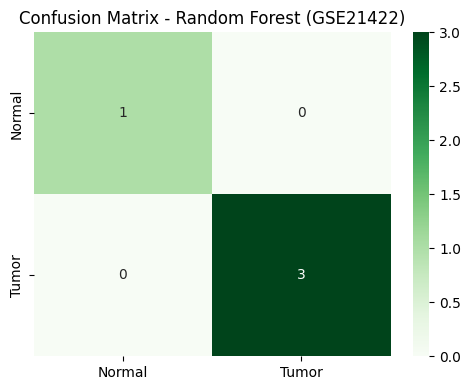

In [15]:
rf_preds = models['Random Forest'].predict(X_test_sel)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title('Confusion Matrix - Random Forest (GSE21422)')
plt.tight_layout()
plt.savefig('gse21422_confusion.png', dpi=150)
plt.show()

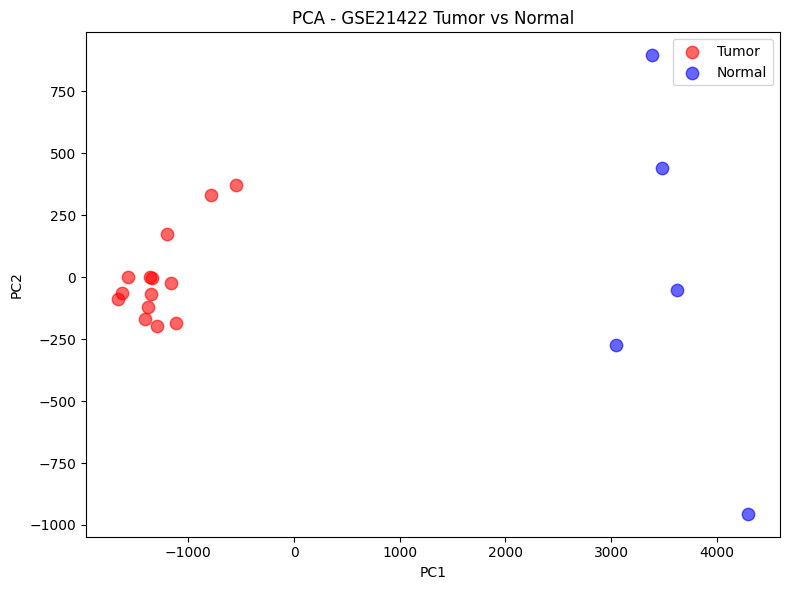

Accuracies: {'Random Forest': 1.0, 'SVM': 1.0, 'Logistic Regression': 1.0}


In [14]:
X_all_imp = imputer.transform(X)
X_all_sel = selector.transform(X_all_imp)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_sel)

plt.figure(figsize=(8, 6))
for label, color, name in [(1, 'red', 'Tumor'), (0, 'blue', 'Normal')]:
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                c=color, label=name, alpha=0.6, s=80)
plt.title('PCA - GSE21422 Tumor vs Normal')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('gse21422_pca.png', dpi=150)
plt.show()

print('Accuracies:', results)